# Germany Power Market Analysis

Data-driven analysis of the German electricity market using real hourly data from the SMARD API (Bundesnetzagentur).

**Modules:**
- Module A: Data collection, negative price analysis, correlation study
- Module B: Peak/off-peak arbitrage backtest
- Module C: Month x hour heatmap
- Module D: Random Forest price forecasting model

**Data source:** [SMARD - Bundesnetzagentur](https://www.smard.de)

**Filter codes:**
| Filter | Description |
|--------|-------------|
| 4169 | Day-ahead price (EUR/MWh) |
| 4067 | Wind onshore generation (MWh) |
| 4068 | Solar PV generation (MWh) |
| 410  | Total consumption (MWh) |

## Module A — Data Collection & Exploratory Analysis

In [1]:
import requests
import pandas as pd
import time
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

print('Libraries loaded.')

Libraries loaded.


In [2]:
# Fetch latest price block from SMARD API
url_index = 'https://www.smard.de/app/chart_data/4169/DE/index_hour.json'
timestamps = requests.get(url_index).json()['timestamps']
latest_ts = max(timestamps)
print(f'Latest timestamp: {latest_ts}')

url_data = f'https://www.smard.de/app/chart_data/4169/DE/4169_DE_hour_{latest_ts}.json'
series = requests.get(url_data).json()['series']

df = pd.DataFrame(series, columns=['timestamp_ms', 'price_eur_mwh'])
df['datetime'] = pd.to_datetime(df['timestamp_ms'], unit='ms')
df = df.dropna(subset=['price_eur_mwh'])[['datetime', 'price_eur_mwh']]

print(df.head(10))
print(f'\nTotal rows     : {len(df)}')
print(f'Min price      : {df["price_eur_mwh"].min():.2f} EUR/MWh')
print(f'Max price      : {df["price_eur_mwh"].max():.2f} EUR/MWh')
print(f'Negative hours : {(df["price_eur_mwh"] < 0).sum()}')

Latest timestamp: 1775426400000
             datetime  price_eur_mwh
0 2026-04-05 22:00:00           3.24
1 2026-04-05 23:00:00           1.99
2 2026-04-06 00:00:00           1.04
3 2026-04-06 01:00:00           1.36
4 2026-04-06 02:00:00           1.06
5 2026-04-06 03:00:00           2.11
6 2026-04-06 04:00:00           1.99
7 2026-04-06 05:00:00           1.33
8 2026-04-06 06:00:00          -0.94
9 2026-04-06 07:00:00         -11.10

Total rows     : 72
Min price      : -125.64 EUR/MWh
Max price      : 194.03 EUR/MWh
Negative hours : 20


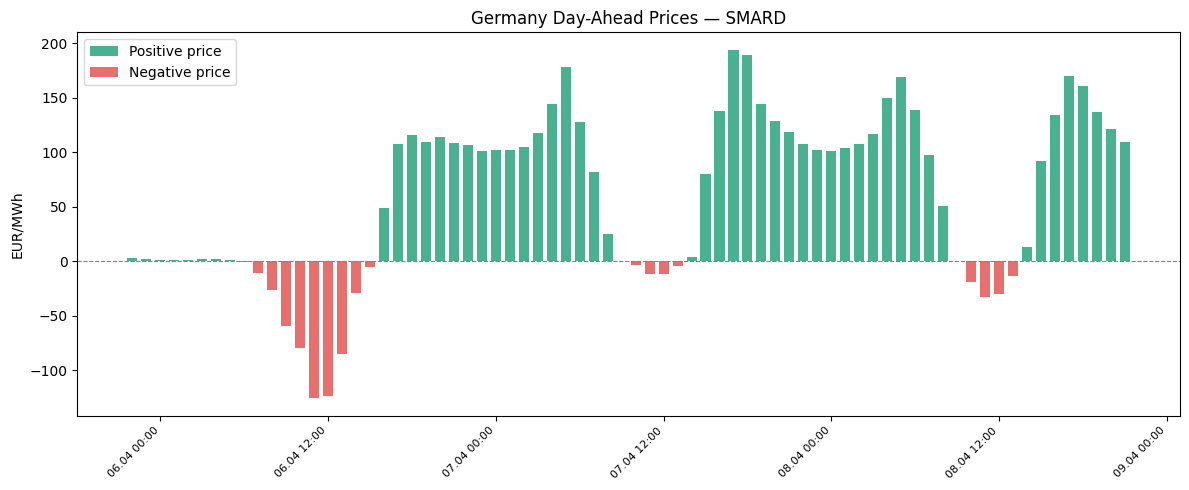

In [3]:
# Plot positive vs negative prices
fig, ax = plt.subplots(figsize=(12, 5))
positive = df[df['price_eur_mwh'] >= 0]
negative = df[df['price_eur_mwh'] < 0]

ax.bar(positive['datetime'], positive['price_eur_mwh'], width=0.03, color='#1D9E75', alpha=0.8, label='Positive price')
ax.bar(negative['datetime'], negative['price_eur_mwh'], width=0.03, color='#E24B4A', alpha=0.8, label='Negative price')
ax.axhline(y=0, color='gray', linewidth=0.8, linestyle='--')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m %H:%M'))
plt.xticks(rotation=45, ha='right', fontsize=8)
ax.set_ylabel('EUR/MWh')
ax.set_title('Germany Day-Ahead Prices — SMARD')
ax.legend()
plt.tight_layout()
plt.show()

In [4]:
# Fetch 1 year of data for all variables
def fetch_data(filter_no, col_name):
    """Fetch 1 year of hourly data for a given SMARD filter."""
    url_index = f'https://www.smard.de/app/chart_data/{filter_no}/DE/index_hour.json'
    timestamps = requests.get(url_index).json()['timestamps']
    last_52_weeks = timestamps[-52:]

    series = []
    for i, ts in enumerate(last_52_weeks):
        url = f'https://www.smard.de/app/chart_data/{filter_no}/DE/{filter_no}_DE_hour_{ts}.json'
        series.extend(requests.get(url).json()['series'])
        time.sleep(0.3)
        if i % 10 == 0:
            print(f'  {col_name}: {i+1}/52 blocks fetched...')

    df = pd.DataFrame(series, columns=['timestamp_ms', col_name])
    df['datetime'] = pd.to_datetime(df['timestamp_ms'], unit='ms')
    return df[['datetime', col_name]]

print('Fetching price data...')
df_price = fetch_data(4169, 'price_eur_mwh')

print('Fetching wind data...')
df_wind = fetch_data(4067, 'wind_mwh')

print('Fetching solar data...')
df_solar = fetch_data(4068, 'solar_mwh')

print('Fetching consumption data...')
df_consumption = fetch_data(410, 'consumption_mwh')

# Merge all into one DataFrame
df_all = df_price.merge(df_wind, on='datetime').merge(df_solar, on='datetime').merge(df_consumption, on='datetime')
df_all = df_all.dropna()
df_all['net_surplus_mwh'] = df_all['wind_mwh'] + df_all['solar_mwh'] - df_all['consumption_mwh']
df_all['hour']  = df_all['datetime'].dt.hour
df_all['month'] = df_all['datetime'].dt.month

print(f'\nMerged dataset: {len(df_all)} rows')
print(df_all.head())

Fetching price data...
  price_eur_mwh: 1/52 blocks fetched...
  price_eur_mwh: 11/52 blocks fetched...
  price_eur_mwh: 21/52 blocks fetched...
  price_eur_mwh: 31/52 blocks fetched...
  price_eur_mwh: 41/52 blocks fetched...
  price_eur_mwh: 51/52 blocks fetched...
Fetching wind data...
  wind_mwh: 1/52 blocks fetched...
  wind_mwh: 11/52 blocks fetched...
  wind_mwh: 21/52 blocks fetched...
  wind_mwh: 31/52 blocks fetched...
  wind_mwh: 41/52 blocks fetched...
  wind_mwh: 51/52 blocks fetched...
Fetching solar data...
  solar_mwh: 1/52 blocks fetched...
  solar_mwh: 11/52 blocks fetched...
  solar_mwh: 21/52 blocks fetched...
  solar_mwh: 31/52 blocks fetched...
  solar_mwh: 41/52 blocks fetched...
  solar_mwh: 51/52 blocks fetched...
Fetching consumption data...
  consumption_mwh: 1/52 blocks fetched...
  consumption_mwh: 11/52 blocks fetched...
  consumption_mwh: 21/52 blocks fetched...
  consumption_mwh: 31/52 blocks fetched...
  consumption_mwh: 41/52 blocks fetched...
  consum

In [5]:
# Negative price summary
print(f'Total hours          : {len(df_all)}')
print(f'Negative price hours : {(df_all["price_eur_mwh"] < 0).sum()}')
print(f'Negative price rate  : {(df_all["price_eur_mwh"] < 0).mean()*100:.1f}%')

# Monthly breakdown
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

monthly = df_all.groupby('month').agg(
    total_hours   = ('price_eur_mwh', 'count'),
    negative_hours= ('price_eur_mwh', lambda x: (x < 0).sum()),
    avg_price     = ('price_eur_mwh', 'mean'),
    min_price     = ('price_eur_mwh', 'min'),
).reset_index()
monthly['neg_rate_%'] = (monthly['negative_hours'] / monthly['total_hours'] * 100).round(1)
monthly['month_name'] = monthly['month'].map(month_names)
print(monthly[['month_name','negative_hours','neg_rate_%','avg_price','min_price']].to_string(index=False))

Total hours          : 8615
Negative price hours : 567
Negative price rate  : 6.6%
month_name  negative_hours  neg_rate_%  avg_price  min_price
       Jan               2         0.3 110.142097      -0.01
       Feb               7         1.0  96.505060      -0.25
       Mar              33         4.4  99.460484     -11.76
       Apr              71        12.3  76.155757    -129.81
       May             129        17.3  67.323118    -250.32
       Jun             141        19.6  64.027528     -99.01
       Jul              12         1.6  87.791573      -2.26
       Aug              64         8.6  76.938723     -61.08
       Sep              60         8.3  83.528236     -53.40
       Oct              48         6.5  84.350591      -4.98
       Nov               0         0.0 101.928556       4.93
       Dec               0         0.0  93.430296       3.51


In [6]:
# Correlation analysis
corr = df_all[['price_eur_mwh','wind_mwh','solar_mwh','consumption_mwh','net_surplus_mwh']].corr()
print('Correlation with price:')
print(corr['price_eur_mwh'].round(2))

# Top 10 lowest price hours
print('\nTop 10 lowest price hours:')
lowest = df_all.nsmallest(10, 'price_eur_mwh')
print(lowest[['datetime','price_eur_mwh','wind_mwh','solar_mwh']].to_string(index=False))

Correlation with price:
price_eur_mwh      1.00
wind_mwh          -0.30
solar_mwh         -0.55
consumption_mwh    0.31
net_surplus_mwh   -0.86
Name: price_eur_mwh, dtype: float64

Top 10 lowest price hours:
           datetime  price_eur_mwh  wind_mwh  solar_mwh
2025-05-11 11:00:00        -250.32   1793.00   44042.25
2025-05-11 12:00:00        -230.98   1899.00   41823.00
2025-05-11 10:00:00        -212.82   1843.50   44887.25
2025-05-01 11:00:00        -129.99    689.25   44333.25
2025-04-27 11:00:00        -129.81   1287.50   42529.75
2026-04-06 11:00:00        -125.64   4174.94   39255.97
2026-04-06 12:00:00        -123.54   3883.31   37434.68
2025-05-01 12:00:00        -118.11    719.00   41661.75
2025-04-27 12:00:00        -116.61   1098.25   40607.25
2025-05-10 11:00:00        -114.53   1046.25   43269.25


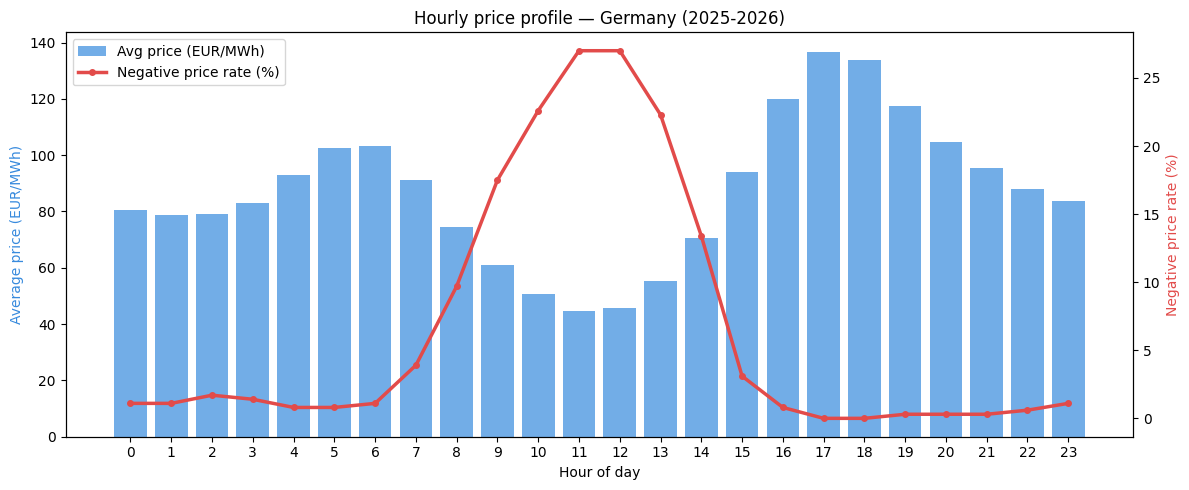

In [7]:
# Hourly price profile
hourly = df_all.groupby('hour').agg(
    avg_price    = ('price_eur_mwh', 'mean'),
    neg_rate     = ('price_eur_mwh', lambda x: (x < 0).mean() * 100),
).round(1)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(hourly.index, hourly['avg_price'], color='#378ADD', alpha=0.7, label='Avg price (EUR/MWh)')
ax1.set_ylabel('Average price (EUR/MWh)', color='#378ADD')
ax1.set_xlabel('Hour of day')

ax2 = ax1.twinx()
ax2.plot(hourly.index, hourly['neg_rate'], color='#E24B4A', linewidth=2.5, marker='o', markersize=4, label='Negative price rate (%)')
ax2.set_ylabel('Negative price rate (%)', color='#E24B4A')
ax1.set_xticks(range(24))
ax1.set_title('Hourly price profile — Germany (2025-2026)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')
plt.tight_layout()
plt.show()

## Module B — Trading Strategy Backtest

**Strategy:** Solar valley arbitrage — buy at hour 11 (solar peak), sell at hour 17 (evening peak).

In [8]:
df_all['date'] = df_all['datetime'].dt.date

buy  = df_all[df_all['hour'] == 11][['date','price_eur_mwh']].rename(columns={'price_eur_mwh':'buy_price'})
sell = df_all[df_all['hour'] == 17][['date','price_eur_mwh']].rename(columns={'price_eur_mwh':'sell_price'})

strategy = buy.merge(sell, on='date')
strategy['daily_pnl']    = strategy['sell_price'] - strategy['buy_price']
strategy['cum_pnl']      = strategy['daily_pnl'].cumsum()

# Realistic version with transaction costs
commission = 0.5  # EUR/MWh per trade
min_spread = 10   # minimum spread to execute trade
strategy['real_pnl'] = strategy['daily_pnl'] - (2 * commission)
strategy_filtered = strategy[strategy['daily_pnl'].abs() > min_spread]

print(f'Total days          : {len(strategy)}')
print(f'Winning days        : {(strategy["daily_pnl"] > 0).sum()}')
print(f'Losing days         : {(strategy["daily_pnl"] < 0).sum()}')
print(f'Win rate            : {(strategy["daily_pnl"] > 0).mean()*100:.1f}%')
print(f'Total P&L (raw)     : {strategy["daily_pnl"].sum():.2f} EUR/MWh')
print(f'Best day            : {strategy["daily_pnl"].max():.2f} EUR')
print(f'Worst day           : {strategy["daily_pnl"].min():.2f} EUR')
print(f'\nWith costs (filtered):')
print(f'Trades executed     : {len(strategy_filtered)}')
print(f'Realistic P&L       : {strategy_filtered["real_pnl"].sum():.2f} EUR/MWh')

Total days          : 359
Winning days        : 348
Losing days         : 11
Win rate            : 96.9%
Total P&L (raw)     : 33120.82 EUR/MWh
Best day            : 409.24 EUR
Worst day           : -53.09 EUR

With costs (filtered):
Trades executed     : 342
Realistic P&L       : 32736.68 EUR/MWh


## Module C — Month x Hour Heatmap

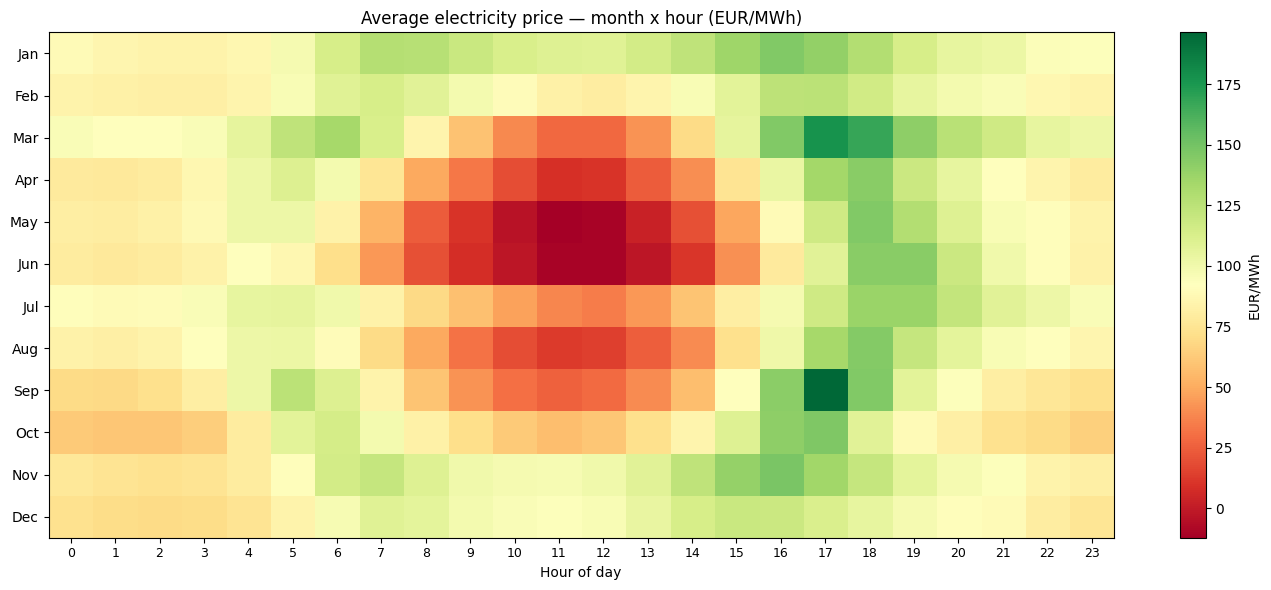

In [9]:
pivot = df_all.pivot_table(
    values='price_eur_mwh',
    index='month',
    columns=df_all['datetime'].dt.hour,
    aggfunc='mean'
)

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn')
ax.set_xticks(range(24))
ax.set_xticklabels(range(24), fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([month_labels[m-1] for m in pivot.index])
ax.set_xlabel('Hour of day')
ax.set_title('Average electricity price — month x hour (EUR/MWh)')
plt.colorbar(im, ax=ax, label='EUR/MWh')
plt.tight_layout()
plt.show()

## Module D — Price Forecasting Model

Features: lag prices (24h, 48h, 168h), wind, solar, consumption, net surplus, hour, month, day of week.

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Feature engineering
df_model = df_all.copy()
df_model['price_lag24']  = df_model['price_eur_mwh'].shift(24)
df_model['price_lag48']  = df_model['price_eur_mwh'].shift(48)
df_model['price_lag168'] = df_model['price_eur_mwh'].shift(168)
df_model['dayofweek']    = df_model['datetime'].dt.dayofweek
df_model = df_model.dropna()

features = ['hour','month','dayofweek',
            'solar_mwh','wind_mwh','consumption_mwh',
            'net_surplus_mwh','price_lag24','price_lag48','price_lag168']

X = df_model[features]
y = df_model['price_eur_mwh']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Linear Regression baseline
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(f'Linear Regression  → MAE: {mean_absolute_error(y_test, y_pred_lr):.2f}  R2: {r2_score(y_test, y_pred_lr):.3f}')
print(f'Random Forest      → MAE: {mean_absolute_error(y_test, y_pred_rf):.2f}  R2: {r2_score(y_test, y_pred_rf):.3f}')

Linear Regression  → MAE: 19.02  R2: 0.765
Random Forest      → MAE: 16.70  R2: 0.782


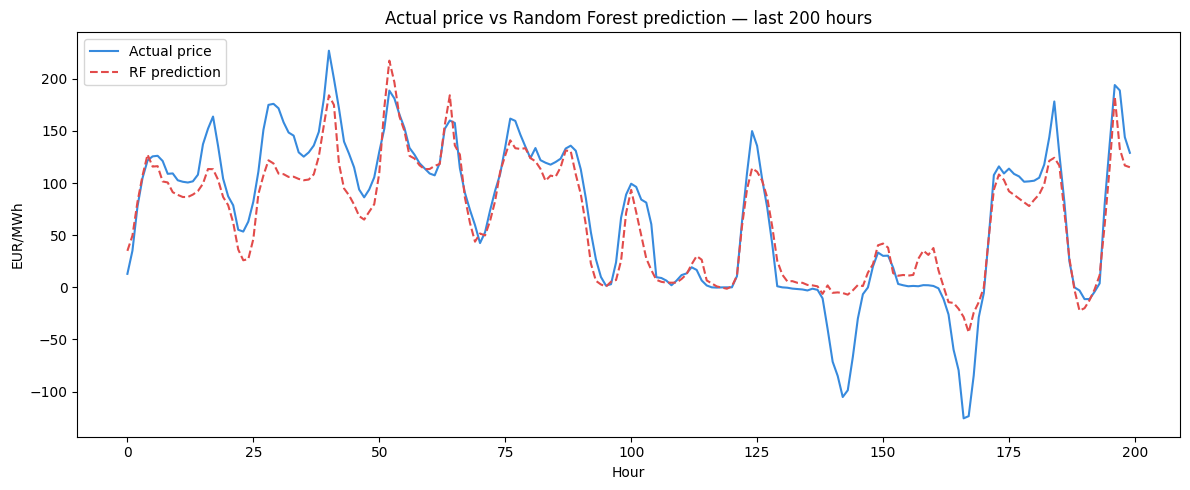

In [11]:
# Actual vs predicted — last 200 hours
fig, ax = plt.subplots(figsize=(12, 5))
n = 200
ax.plot(range(n), y_test.values[-n:], color='#378ADD', linewidth=1.5, label='Actual price')
ax.plot(range(n), y_pred_rf[-n:], color='#E24B4A', linewidth=1.5, linestyle='--', label='RF prediction')
ax.set_xlabel('Hour')
ax.set_ylabel('EUR/MWh')
ax.set_title('Actual price vs Random Forest prediction — last 200 hours')
ax.legend()
plt.tight_layout()
plt.show()

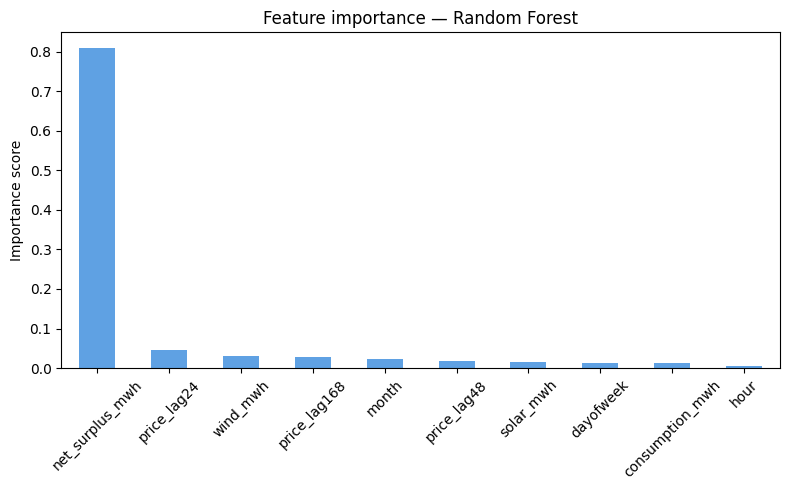

net_surplus_mwh    0.808507
price_lag24        0.046994
wind_mwh           0.029807
price_lag168       0.026858
month              0.023203
price_lag48        0.017846
solar_mwh          0.015839
dayofweek          0.012353
consumption_mwh    0.012282
hour               0.006310
dtype: float64


In [12]:
# Feature importance
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='bar', ax=ax, color='#378ADD', alpha=0.8)
ax.set_title('Feature importance — Random Forest')
ax.set_ylabel('Importance score')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print(importances)